# *Stats project*

By: Samuel Alvarez & Maxime Blaise

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st


In [2]:
df = pd.read_csv('spotify.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  str    
 1   album_name        113999 non-null  str    
 2   track_name        113999 non-null  str    
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             114000 non-nu

## Dataset Description:
The dataset, loaded from spotify.csv, contains 114,000 entries across 19 columns. It is a sample of song releases available on the Spotify platform, covering a wide range of artists, albums, and musical attributes. The unit of observation is an individual track, and since it captures a snapshot of songs rather than tracking changes over time, it is not a time series. The data appears to come from a kaggle data set of Spotify, making it an observed dataset.For the analysis, we filtered the data down to four key variables — danceability, acousticness, explicit, and track_genre — and further restricted the sample to five genres: pop, rock, hip-hop, classical, and jazz. From this filtered population (~102,000 entries), a working sample of 1,000 observations was drawn with replacement for the statistical analyses.

In [3]:
df.head()

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
variables = ['danceability', 'acousticness', 'track_genre']
df_rawvar = df[variables]
df_var = df_rawvar.dropna().drop_duplicates()
df_var.info()
genre = ['pop', 'rock', 'hip-hop', 'classical', 'jazz']
df_var = df_var[df['track_genre'].isin(genre)]
df_var


<class 'pandas.DataFrame'>
Index: 102547 entries, 0 to 113999
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   danceability  102547 non-null  float64
 1   acousticness  102547 non-null  float64
 2   track_genre   102547 non-null  str    
dtypes: float64(2), str(1)
memory usage: 3.1 MB


C:\Users\salva\AppData\Local\Temp\ipykernel_22416\2309154916.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_var = df_var[df['track_genre'].isin(genre)]


,danceability,acousticness,track_genre
16000,0.643,0.5930,classical
16001,0.484,0.3650,classical
16002,0.608,0.5810,classical
16003,0.695,0.5960,classical
16004,0.583,0.5810,classical
...,...,...,...
91985,0.547,0.0393,rock
91986,0.459,0.2960,rock
91987,0.440,0.0956,rock
91988,0.552,0.4450,rock


## Variables:
* Danceability is a numerical continuous variable with a range from 0 to 1. It represents how suitable a track is for dancing, based on elements like rhythm stability, beat strength, and overall tempo. A value closer to 1 means the song is highly danceable, while values near 0 indicate it is not.
* Acousticness is a numerical continuous variable also ranging from 0 to 1. It reflects the degree to which a track is acoustic rather than electronically produced. A high value suggests the track is predominantly acoustic, while a low value indicates heavy use of electronic or amplified instruments.
* Track genre is a categorical nominal variable that classifies each song into a musical genre. The dataset contains a wide variety of genres, though the analysis focuses on five: classical, hip-hop, jazz, pop, and rock. It is an observed label assigned to each track based on its musical style.

In [5]:
df_samplevar = df_var.sample(n=1000, replace=True, random_state=42)
df_samplevar = df_samplevar.reset_index(drop=True)
df_var = df_var.reset_index(drop=True)

**Here we define our random sample to do inferential stats on the whole population.**

In [6]:
df_samplevar

,danceability,acousticness,track_genre
0,0.717,0.708000,rock
1,0.689,0.369000,hip-hop
2,0.609,0.357000,hip-hop
3,0.540,0.046600,hip-hop
4,0.655,0.476000,hip-hop
...,...,...,...
995,0.467,0.000187,rock
996,0.664,0.031600,jazz
997,0.387,0.955000,classical
998,0.579,0.020200,rock


# Linear regression

**We plot the scatter, searching for hints of a possible correlation, linearization, etc.**

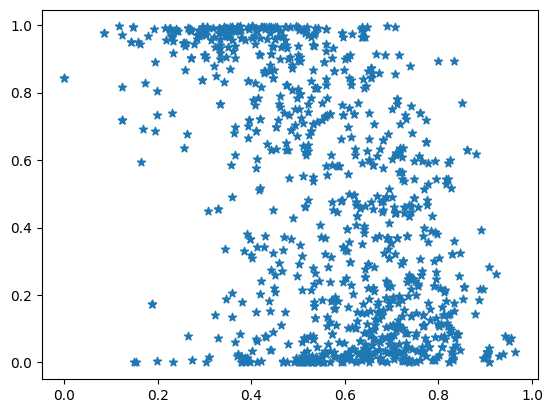

In [7]:
plt.scatter(df_samplevar['danceability'],df_samplevar['acousticness'],marker='*')
plt.show()

**After plotting we realize that the scatter has a possible negative correlation and that the variables of y can be predicted with x.**

In [8]:
er = st.linregress(df_samplevar['danceability'],df_samplevar['acousticness'])
er

LinregressResult(slope=np.float64(-1.0679953350368996), intercept=np.float64(1.0706183872635655), rvalue=np.float64(-0.521022548784872), pvalue=np.float64(1.1147088836833166e-70), stderr=np.float64(0.05538254722812142), intercept_stderr=np.float64(0.03305455949992995))

**We use scipy funtion of linear regression to get all the values of the linear regression of the sampled data. We observe as result of the function, the slope , the intercept, the r value for this regression line, the p value for the hypotesis test, and both errors for the slope and intercept.**

In [9]:
n = len(df_samplevar)
x = df_samplevar.danceability
y = df_samplevar.acousticness
b = er.slope
a = er.intercept
hy = a + b*x
e = y-hy
sse = np.sum(e**2)
hs2 = (sse)/(n)

**After getting the linear regression values we continue calculating the mean squared error, trying to observe a mean error of almost 0.**

In [10]:
hs2

np.float64(0.09750933464891161)

**After seeing that its plausible to continue with this regression line we plot it for the sake of ilustratiation.**

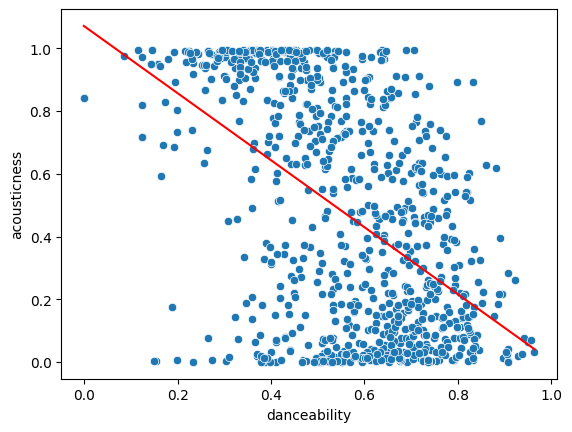

In [11]:
fit = [b,a]
poly = np.poly1d(fit)
rang = max(x)-min(x)
lb = min(x) - (rang/1000)
lu = max(x) + (rang/1000)
z = [lb,lu]
sns.scatterplot(data=df_samplevar, x=df_samplevar['danceability'],y=df_samplevar['acousticness'], markers='*')
plt.plot(z,poly(z),'r-')

**We calculate the r^2, which will tell how much of the variation of Y is explained by the model. Also we retrive the p value as estimator for our hypotesis test over the relevance of the slope.**

In [12]:
R2 = (er.rvalue)**2
p = er.pvalue
p, R2

(np.float64(1.1147088836833166e-70), np.float64(0.2714644963422843))

**Also for better ilustration we pplot the bands were the outliners are, so all points outside the blue lines are consider as outliners.**

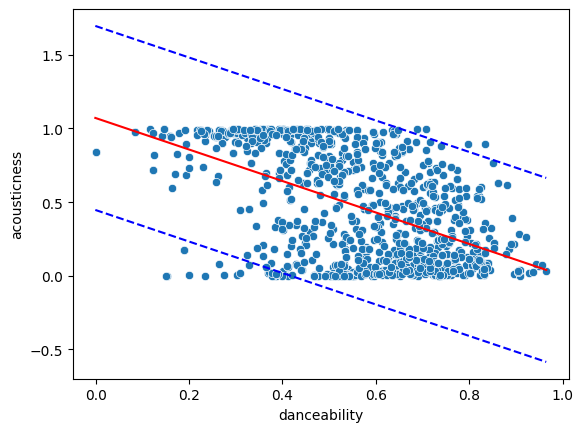

In [13]:
sns.scatterplot(data=df_samplevar, x=x,y=y,markers='x')
plt.plot(z,poly(z),'r-')
plt.plot(z,poly(z) + 2*np.sqrt(hs2), 'b--')
plt.plot(z,poly(z) - 2*np.sqrt(hs2), 'b--')

In [14]:
x0 = np.linspace(lb,lu,1000)
hy0 = poly(x0)
v0 = (np.var(x)+(x0-np.mean(x))**2) / (n*np.var(x))
alpha = 0.05
t = st.t.ppf(1-(alpha/2),n)

In [15]:
ss_x = n*np.var(x)
v0 = ((1/n) + ((x0-np.mean(x))**2)) / ss_x


In [16]:
eps = t*np.sqrt(v0*hs2)
mean_lo = hy0-eps
mean_hi = hy0 + eps

In [17]:
eps2 = t*np.sqrt(hs2*(1+v0))
outp_lo = hy0-eps2
outp_hi = hy0+eps2

**For even better representation, we plot also the CI of the linear model for an alpha = 0.05. So what´s inside the blue lines is the CI of the linear regression.**

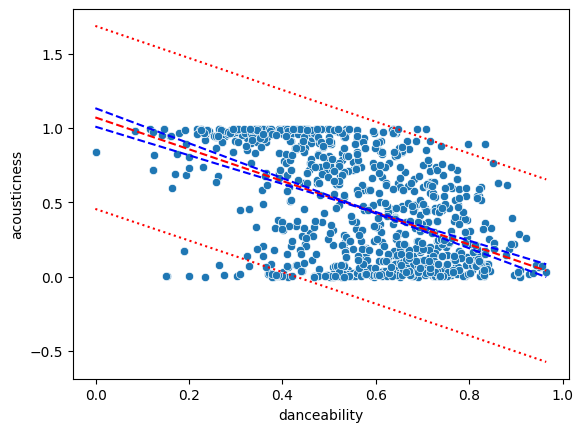

In [18]:
sns.scatterplot(data=df_samplevar,x=x,y=y,markers='*')
plt.plot(x0,poly(x0),'r--')
plt.plot(x0, mean_lo, 'b--')
plt.plot(x0, mean_hi , 'b--')
plt.plot(x0, outp_lo, 'r:')
plt.plot(x0, outp_hi, 'r:')

### After seeing all of this information, we continue trying to verify that the model it´s really a good estimator of the variable acousticness. By that reason we carry an analysis of residuals to find if it isn´t just noise.

<function matplotlib.pyplot.show(close=None, block=None)>

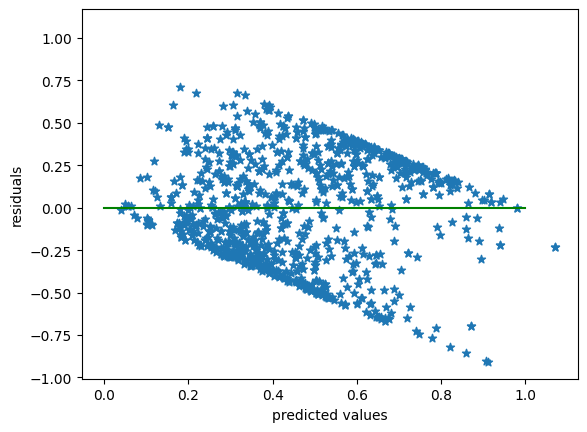

In [19]:
plt.scatter(x=hy,y=e,marker='*')
plt.plot(min(hy),max(hy),(0,0),'g')
plt.xlabel('predicted values')
plt.ylabel('residuals')
plt.show

**For the first test of homocedasticity we have a big problem, a clear hetereocedaticity. Which means that depending on the values of X we most likely have certain levels of residuals. For a linear regression model this is terrible and inflicts one of the most important principles.**

Text(0, 0.5, 'actual values')

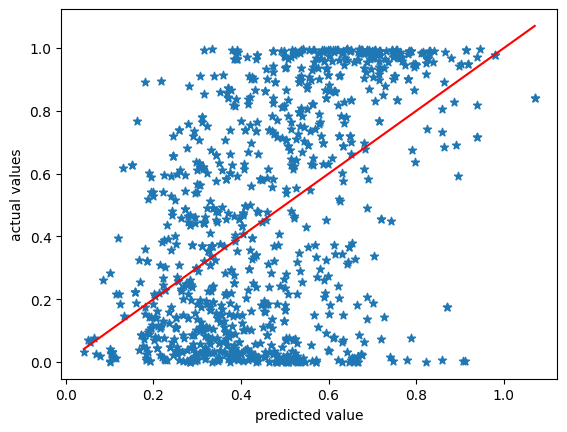

In [20]:
plt.scatter(x=hy,y=y,marker='*')
plt.plot((min(hy),max(hy)),(min(hy),max(hy)),'r')
plt.xlabel('predicted value')
plt.ylabel('actual values')

**Here, too, we observe that, at first, the model captures a large portion of the actual values; however, as the value of X increases, the model estimates fewer and fewer values.**

Text(0.5, 1.0, 'q-q plot')

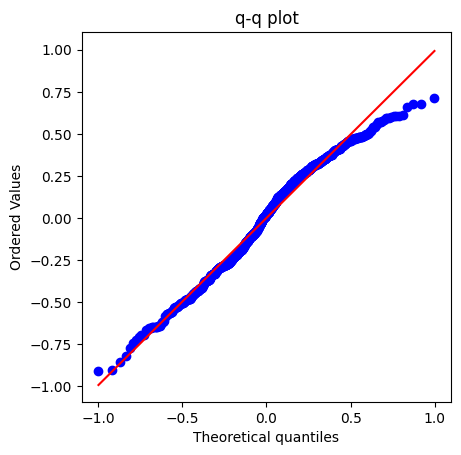

In [21]:
dist = st.norm(loc=0,scale=np.sqrt(hs2))
st.probplot(e,dist=dist,plot=plt)
plt.axis('square')
plt.title('q-q plot')

**We procced with the second test of normality. For this test we use a q-q plot, and we notice that the residuals follows the normal distribution very closely except for the end. This means that the residuals meet the normality characteristic and only that with heavier tails, which explains why the blue dots get out of the red line at the end.**

In [22]:
d = np.sum(np.diff(e)**2)/sse
d



np.float64(2.0425535706311195)

**Finally for the last test, we proced with a Durbin Watson test for autocorrelation. We get a d really near 2, so we omit the rest of the test. This result mean that the residuals are uncorrelated between them.**

In [23]:
q = x**2
er2 = st.linregress(q,y)
er2

LinregressResult(slope=np.float64(-0.9541767327374051), intercept=np.float64(0.8022587406241224), rvalue=np.float64(-0.5102120991552864), pvalue=np.float64(2.2245532298618173e-67), stderr=np.float64(0.05091383342148235), intercept_stderr=np.float64(0.02069133317669303))

*After the experiment, we decided to try to linearize the variable x in order to find a better model with a higher R value. However, we tried with several exponents and functions with no luck, the best we got is a r = -0.51, which is still lower than the oiginal model.*

<Axes: xlabel='danceability', ylabel='acousticness'>

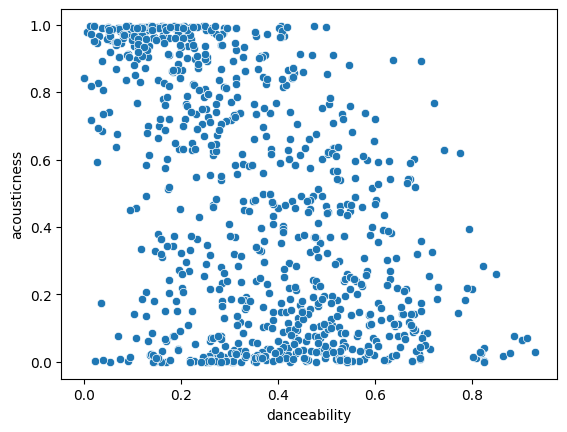

In [24]:
q
sns.scatterplot(data=df_samplevar,x=q,y=y)

In [25]:
c = er2.intercept
d = er2.slope
hy2 = c + d*q
e2 = y-hy2
sse2 = np.sum(e**2)
hs22 = (sse2)/(n-1)
hs22


np.float64(0.09760694159050211)

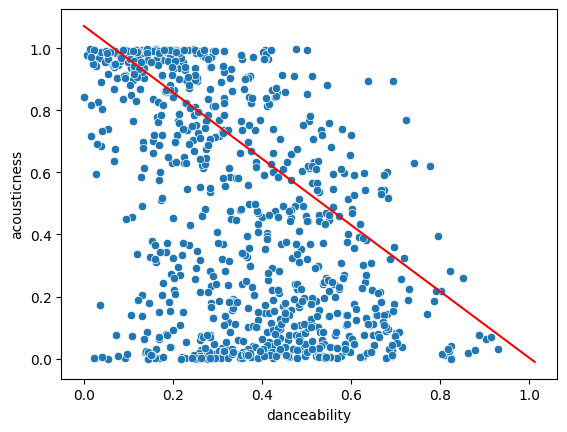

In [26]:
fit2 = [d,c]
poly2 = np.poly1d(fit)
rang2 = max(z)-min(z)
lb = min(x) -(rang2/1000)
lu = max(x) +(rang/20)
w = [lb,lu]
sns.scatterplot(data=df_samplevar,x=q,y=y,markers='*')
plt.plot(w,poly2(w),'r-')

*Here we observe the regression line for this Trial*

### Conclusion 

The linear regression analysis reveals a statistically significant but fundamentally flawed relationship between Acousticness and Danceability. While the p-value p < 0.05 confirms that the slope is statistically different from zero and the Durbin-Watson statistic with d = 2.04 indicates no autocorrelation, the model's predictive power is weak, with an R^2 of only 0.27. Critical violations of linear regression assumptions were identified during residual analysis; specifically, the residuals vs. fitted plot demonstrated clear heteroscedasticity through a negative correlation pattern. Although the Q-Q plot suggests the residuals follow a normal distribution with some heavy tails, the presence of numerous outliers and the failure of the homoscedasticity assumption render the model unreliable. Despite attempts at linearization, the R value did not improve, leading to the conclusion that a simple linear model is insufficient to accurately explain the variance in Spotify's danceability metrics.


# ANOVA

**We start defining the varibles for the anova test, which are the danceability and the track genre.**

In [27]:
df_anova = df_samplevar[['danceability','track_genre']]
df_anova

,danceability,track_genre
0,0.717,rock
1,0.689,hip-hop
2,0.609,hip-hop
3,0.540,hip-hop
4,0.655,hip-hop
...,...,...
995,0.467,rock
996,0.664,jazz
997,0.387,classical
998,0.579,rock


**We plot the boxplots, looking for clear signs of differences between the groups. So we can expect for the result that possibly the categorical model can explain the values of Y.**

<Axes: xlabel='track_genre', ylabel='danceability'>

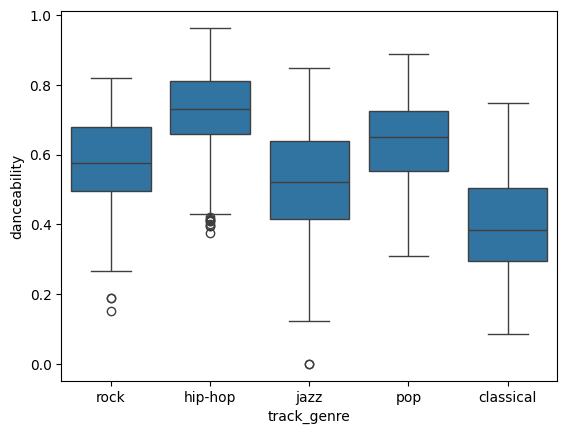

In [28]:
sns.boxplot(data=df_anova,x='track_genre',y='danceability')

In [29]:
k = 5
n = 225
df_model = k-1
df_error = n-1-(k-1)
df_total = (n-1)

**We prepare the values to calculate the anova table, by gettinf the df, k and n values.**

In [30]:
dic = {'rock': 1, 'hip-hop': 2, 'jazz': 3, 'pop': 4, 'classical': 5}
df_anova['num_genre'] = df_anova['track_genre'].map(dic)
df_anova

,danceability,track_genre,num_genre
0,0.717,rock,1
1,0.689,hip-hop,2
2,0.609,hip-hop,2
3,0.540,hip-hop,2
4,0.655,hip-hop,2
...,...,...,...
995,0.467,rock,1
996,0.664,jazz,3
997,0.387,classical,5
998,0.579,rock,1


**We also prepare the dataframe which is going to be used to search the Fisher estimator to conduce a hipotesis test for variances.**

In [31]:
df_anova = df_samplevar[['danceability', 'track_genre']].copy()
df_anova['idx'] = df_anova.groupby('track_genre').cumcount()
df_pivot = df_anova.pivot(index='idx', columns='track_genre', values='danceability')
df_pivot.columns.name = None
df_pivot


,classical,hip-hop,jazz,pop,rock
idx,,,,,
0,0.179,0.689,0.262,0.524,0.717
1,0.343,0.609,0.613,0.619,0.682
2,0.365,0.540,0.230,0.738,0.695
3,0.365,0.655,0.663,0.700,0.188
4,0.328,0.746,0.640,0.722,0.463
...,...,...,...,...,...
220,0.261,0.829,NaN,NaN,NaN
221,0.387,0.584,NaN,NaN,NaN
222,NaN,0.537,NaN,NaN,NaN


**We use a function which gave us all the values from our anova table.**

In [32]:
y = df_pivot.to_numpy()
def fisher_test(y):
    k = y.shape[1]
    ni = np.array([np.sum(~np.isnan(y[:, i])) for i in range(k)])
    yb = np.nanmean(y)
    yib = np.nanmean(y, axis=0)
    ssm = np.nansum(ni * (yib - yb)**2)
    sse = np.nansum(np.nansum((y - yib)**2))
    n = np.sum(ni)
    f = (ssm / (k-1)) / (sse / (n-k))
    p = st.f.sf(f, k-1, n-k)
    return k, ni, yb, yib, ssm, sse, n, f, p

k, ni, yb, yib, ssm, sse, n, f, p = fisher_test(y)
k, ni, yb, yib, ssm, sse, n, f, p

(5,
 array([222, 225, 145, 203, 205]),
 np.float64(0.56953),
 array([0.39756306, 0.71776   , 0.50956552, 0.63182266, 0.57379512]),
 np.float64(12.821680804411189),
 np.float64(19.032746295588822),
 np.int64(1000),
 np.float64(167.57398278547336),
 np.float64(1.0683963382407417e-109))

**We observe a really big fisher at this point, which shows that there is a difference between two or more groups, meaning that the model could be explanatory.**

In [33]:
si2 = np.array([np.nanvar(y[:, i], ddof=1) for i in range(k)])
for i in range(5):
    for h in range(i+1,5):
        print(f'group {i+1} vs group {h+1} : {si2[i] == si2[h]}')
        

group 1 vs group 2 : False
group 1 vs group 3 : False
group 1 vs group 4 : False
group 1 vs group 5 : False
group 2 vs group 3 : False
group 2 vs group 4 : False
group 2 vs group 5 : False
group 3 vs group 4 : False
group 3 vs group 5 : False
group 4 vs group 5 : False


**To proof the signal from the fisher test, we do a Post hoc analysis. At first we look if the variances between groups are the same based on the sample, and the result is that any group has the same variance.**

In [34]:
si2

array([0.0200454 , 0.01705886, 0.02782301, 0.01606803, 0.01730036])

**We do a hipotesis test comparing every group by pairs, looking if statistically there is a real difference of variance or is just noice.**

In [35]:
for i in range(5):
    for h in range(i+1, 5):
        ni_i = ni[i]
        ni_h = ni[h]
        dof = ni_i + ni_h - 2
        pooled = np.sqrt(((ni_i-1)*si2[i] + (ni_h-1)*si2[h]) / dof)
        d = (yib[i] - yib[h]) / (pooled * np.sqrt(1/ni_i + 1/ni_h))
        p_val = 2 * st.t.sf(abs(d), dof)
        print(f'group{i+1} vs group{h+1} : p = {p_val} ; d = {d}')



group1 vs group2 : p = 3.64712363766965e-86 ; d = -24.857196274407734
group1 vs group3 : p = 2.3147611667030238e-11 ; d = -6.899523237609557
group1 vs group4 : p = 8.760987843377901e-54 ; d = -17.907564354178632
group1 vs group5 : p = 5.723194438007822e-34 ; d = -13.294783184422986
group2 vs group3 : p = 1.2171436941552744e-33 ; d = 13.404495535251707
group2 vs group4 : p = 1.9809873733540473e-11 ; d = 6.892690968607501
group2 vs group5 : p = 2.188879518871118e-26 ; d = 11.377718562885486
group3 vs group4 : p = 9.247508307998736e-14 ; d = -7.766371291526951
group3 vs group5 : p = 7.068658733790073e-05 ; d = -4.022420531225411
group4 vs group5 : p = 7.536230241039799e-06 ; d = 4.5366669707375715


## Conclusion 

The ANOVA test confirms that Track Genre is a highly significant predictor of Danceability across the five selected categories. Initial box plot clusters revealed distinct distributional shifts between groups, suggesting a strong categorical influence on the dependent variable. This was statistically validated by a remarkably high Fisher statistic of 167, which vastly exceeds the critical value and is accompanied by a p-value effectively equal to p < 0.05, providing overwhelming evidence to reject the null hypothesis of equal means. Despite observing differing variances across the samples, subsequent pairwise hypothesis tests resulted in p-values consistently below the 0.05 threshold, confirming that the observed differences are statistically significant rather than random noise. Ultimately, the model demonstrates that a categorical approach effectively explains the variability in danceability, establishing genre as a core explanatory factor within the dataset.